# Using K-Means Clustering to Segment Wholesale Customer Spending

In this notebook, we apply K-Means clustering to explore if we can discover natural spending patterns in the [Wholesale Customers dataset](https://archive.ics.uci.edu/dataset/292/wholesale+customers) from UC Irvine's Machine Learning Repository. This dataset records the annual spending (in monetary units) of 440 wholesale distributor clients in Portugal across six product categories: Fresh, Milk, Grocery, Frozen, Detergents_Paper, and Delicassen. Two extra categorical variables encode the sales channel (1 = Horeca/hotel-restaurant-cafe, 2 = Retail) and region (1 = Lisbon, 2 = Porto, 3 = Other).


| **Feature** | **Type** | **Description** |
|---|---|---|
| Fresh | Continuous | Annual spending on fresh products |
| Milk | Continuous | Annual spending on milk products |
| Grocery | Continuous | Annual spending on grocery products |
| Frozen | Continuous | Annual spending on frozen products |
| Detergents_Paper | Continuous | Annual spending on detergents and paper |
| Delicatessen | Continuous | Annual spending on deli products |

We want to see if we can find groups in the spending patterns without using the channel labels. K-Means will group clients into clusters that share similar purchasing profiles. This type of analysis could help a wholesale distributor tailor their supply plans to different customers depending on their cluster.

---

## Load and Explore Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml_package import KMeans, PCA, StandardScaler

In [4]:
df = pd.read_csv("wholesale_customers.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [11]:
# Keep only the 6 spending features (drop Channel and Region if present)
spend_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
X_spend = df[spend_cols].copy()
channel_labels = df["Channel"].values

X_spend.describe().round(1)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


---

The substantial differences between the maximum and third quartile values in the descriptive stastics table above suggests that the data has a right-skew across each spending category. This can be further confirmed by plotting the distribution of each category.

---

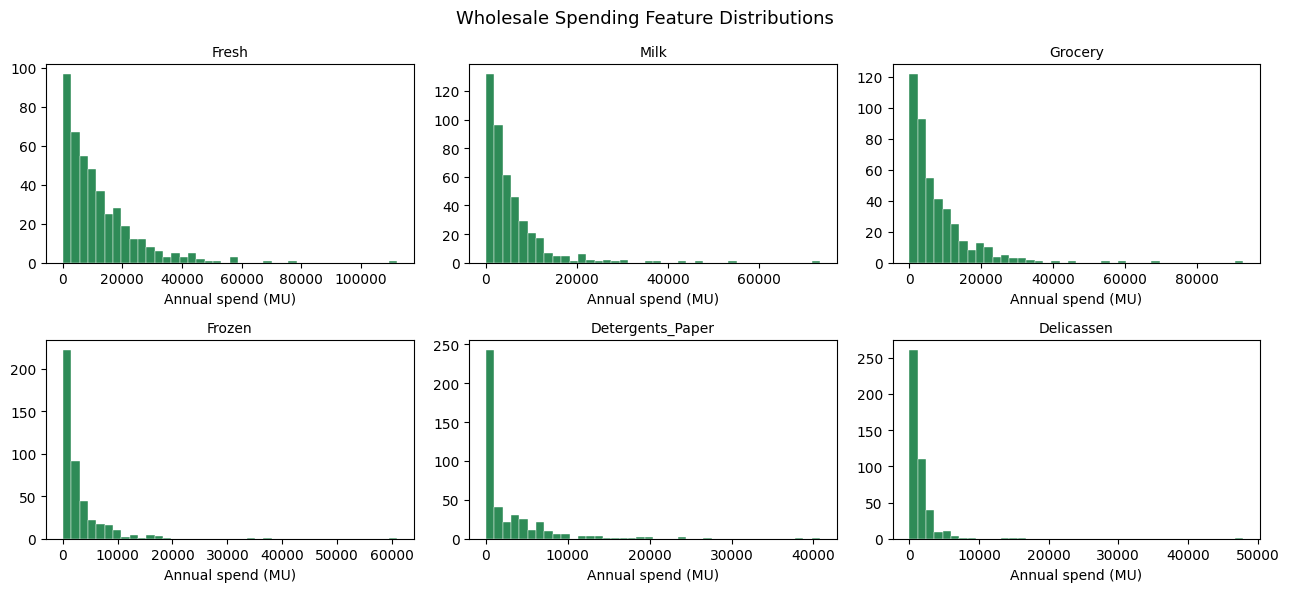

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
fig.suptitle("Wholesale Spending Feature Distributions", fontsize=13)

for ax, col in zip(axes.flat, spend_cols):
    ax.hist(X_spend[col], bins=40, color="seagreen", edgecolor="white", linewidth=0.3)
    ax.set_title(col, fontsize=10); ax.set_xlabel("Annual spend (MU)")
plt.tight_layout()
plt.show()


---

To reduce this right-skew, we take the log transformation of the data.

---

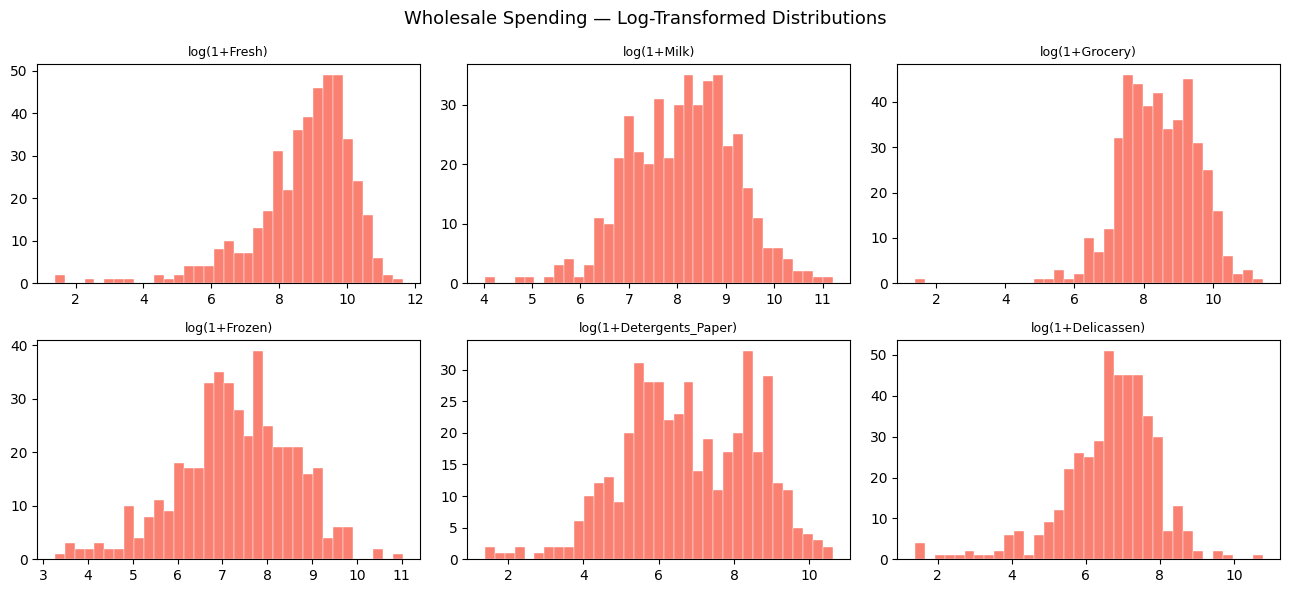

In [26]:
# Log-transform to reduce heavy right skew
X_log = np.log1p(X_spend.values)

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
fig.suptitle("Wholesale Spending — Log-Transformed Distributions", fontsize=13)
for ax, col in zip(axes.flat, spend_cols):
    ax.hist(X_log[:, spend_cols.index(col)], bins=35, color="salmon",
            edgecolor="white", linewidth=0.3)
    ax.set_title(f"log(1+{col})", fontsize=9)
plt.tight_layout()
plt.show()


---

Because the spending amounts vary greater across each feature, we StandardScaler to rescale the data.

---

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
print("Log-transformed and standardised. Shape:", X_scaled.shape)


Log-transformed and standardised. Shape: (440, 6)


## Choosing Our k Value

---

To choose an optimal value of k for this example, we use the elbow method. The elbow plot below plots the inertia, or within-cluster sum of squares, against the number of clusters (k). Inertia is a measure of how dense each cluster, representing how closely packed data points are relative to their respective centroids. Lower inertia (tighter clusters) is generally preferred, and increasing the number of clusters decreases inertia. However, to avoid overfitting, our goal is to find a value of k such that balances the trade-off between having low inertia and having a simple model.

---

  k=2  inertia: 1844.06
  k=3  inertia: 1553.45
  k=4  inertia: 1442.12
  k=5  inertia: 1301.43
  k=6  inertia: 1176.32
  k=7  inertia: 1133.02
  k=8  inertia: 1036.82
  k=9  inertia: 1002.05
  k=10  inertia: 959.17


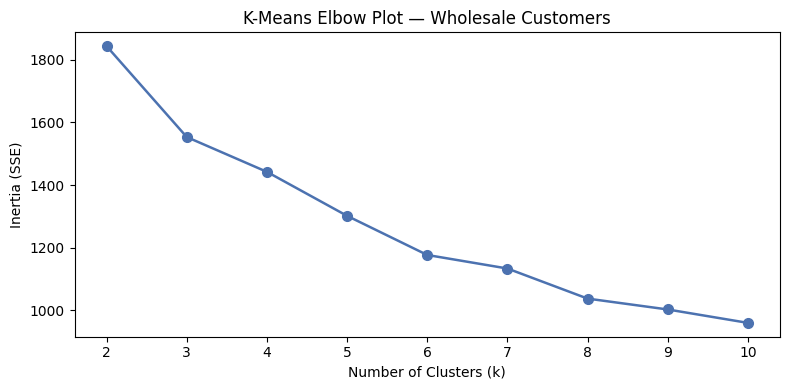

In [28]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, max_iter=300, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"  k={k}  inertia: {km.inertia_:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, "o-", color="#4C72B0", linewidth=1.8, markersize=7)
plt.xlabel("Number of Clusters (k)"); plt.ylabel("Inertia (SSE)")
plt.title("K-Means Elbow Plot — Wholesale Customers")
plt.tight_layout()
plt.show()

---

Based on the elbow plot, we will proceed with k = 3 clusters, as increasing to 4 clusters does not produce a substantial reduction in inertia, while increasing beyong 4 clusters may overfit our data.

---

## Fit K-Means

In [ ]:
# Choose k=3 based on elbow; also try k=2 given channel structure
k_best = 3

km = KMeans(n_clusters=k_best, max_iter=300, random_state=42)
labels = km.fit_predict(X_scaled)

print(f"Cluster sizes: { {i: (labels==i).sum() for i in range(k_best)} }")

Cluster sizes: {0: np.int64(143), 1: np.int64(215), 2: np.int64(82)}


---

The three clusters K-Means found are each fairly populated, with the first cluster having 143 observations, the second 215, and the third 82.

Now, we can plot the clusters. Since the data lives in six dimensions, we use PCA to reduce to two dimensions for visualization. The first two principal components capture the dominant directions of variance.

---

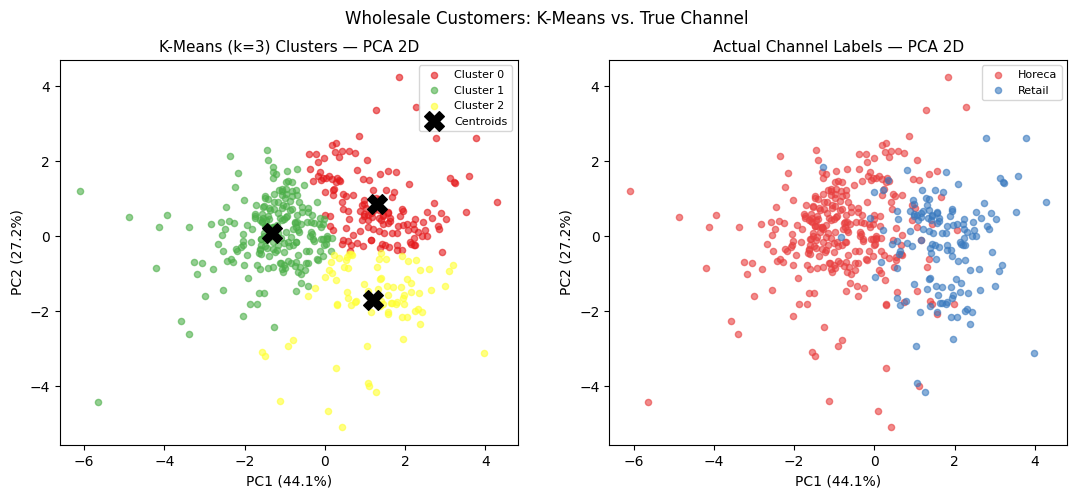

In [30]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

palette = plt.cm.Set1(np.linspace(0, 0.6, k_best))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# K-Means clusters
for i in range(k_best):
    mask = labels == i
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], s=20, alpha=0.6,
                    color=palette[i], label=f"Cluster {i}")

# Plot centroids in PCA space
centroids_2d = pca.transform(km.centroids_)
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                s=200, marker="X", color="black", zorder=5, label="Centroids")
axes[0].set_title(f"K-Means (k={k_best}) Clusters — PCA 2D", fontsize=11)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend(fontsize=8)

# Actual channels (if available)
if channel_labels is not None:
    cmap_ch = {1: "#E84040", 2: "#3A7ABF"}
    for ch, cname in [(1, "Horeca"), (2, "Retail")]:
        mask = channel_labels == ch
        axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], s=20, alpha=0.6,
                        color=cmap_ch[ch], label=cname)
    axes[1].set_title("Actual Channel Labels — PCA 2D", fontsize=11)
    axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    axes[1].legend(fontsize=8)

plt.suptitle("Wholesale Customers: K-Means vs. True Channel", fontsize=12)
plt.show()

---

The left graph above shows that the clusters are nicely separated, suggesting that K-Means worked well for this dataset! Furthermore, the right graph shows that K-Means was able to find farily strong separation between hotel/restaurant/cafe customers and retail customers.

Next, we plot the mean spending by each cluster on each wholesale category.


---

Mean annual spending by cluster (raw units):
           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                 
0        17116.0  10685.0  13497.0  4236.0            5072.0      2874.0
1        12032.0   2068.0   2526.0  3237.0             422.0       905.0
2         2997.0   7045.0  12505.0   608.0            5511.0       797.0


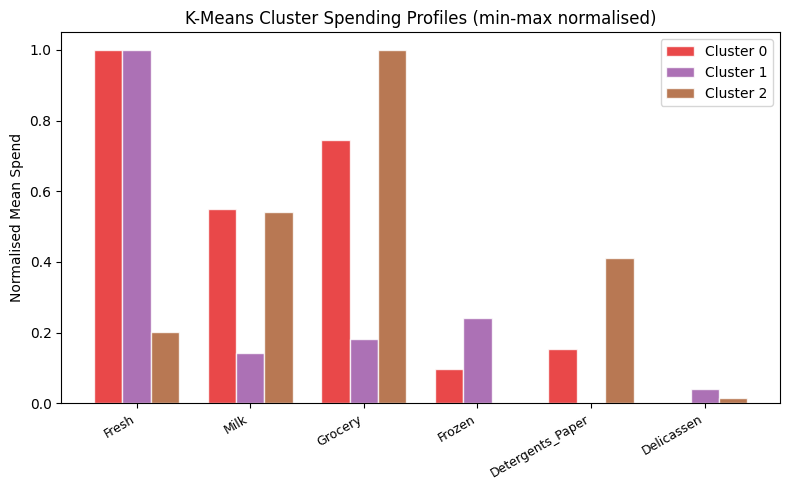

In [32]:
cluster_df = pd.DataFrame(X_spend.values, columns=spend_cols)
cluster_df["Cluster"] = labels

means = cluster_df.groupby("Cluster")[spend_cols].mean()
print("Mean annual spending by cluster (raw units):")
print(means.round(0).to_string())

# Radar chart of normalised cluster means
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(spend_cols))
width = 0.25
cmap = plt.cm.Set1

for i in range(k_best):
    row = means.loc[i]
    normalised = (row - row.min()) / (row.max() - row.min() + 1e-9)
    ax.bar(x_pos + i*width, normalised, width, label=f"Cluster {i}",
           color=cmap(i/k_best), alpha=0.8, edgecolor="white")

ax.set_xticks(x_pos + width)
ax.set_xticklabels(spend_cols, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Normalised Mean Spend")
ax.set_title("K-Means Cluster Spending Profiles (min-max normalised)")
ax.legend()
plt.tight_layout()
plt.show()


---

From this bar plot, we can see some clear spending behaviors by customers in different clusters. Notably, customers in cluster 2 spend very little on Fresh products compared to customers in clusters 0 and 1, instead spending more on Grocery and Detergent/Paper products. Also, we can see that almost all spending by customers in cluster 1 is concentrated in Fresh. Finally, Customers in cluster 0 concentrate most of their spending in Fresh, but also maintain more of a balance with spending on Milk and Grocery products.


Overall, K-Means with k = 3 was able to cleanly separate wholesale customers into three distinct spending archetypes that correspond to operationally meaningful segments:

* Balanced / High Milk (cluster 0): a mixed segment with diverse needs

* High Fresh / Low Grocery (cluster 1): likely hotel/restaurant/cafe clients who buy fresh produce

* High Grocery / High Detergents (cluster 2): likely Retail clients stocking household goods

---